# Two-fault configurations that confuse Correlated Matching — exhaustive, no sampling

**Setup:** rotated surface code, Z-memory, **d = 5, r = 5, p = 2×10⁻⁴**, circuit-level depolarizing
noise, Tesseract-decomposed DEM.

Instead of sampling the circuit, we **combinatorially inject every single DEM error mechanism and
every pair of mechanisms**, build each configuration's exact syndrome, and decode it with MWPM,
CM($\alpha{=}1$) and Pearl($\alpha{=}0.2$). Because each configuration is *constructed*, the ground
truth is known exactly — the injected mechanisms **are** the true error (this is what a DEM sampler's
`return_errors=True` would report, without the sampling): we draw their decomposed edges as the
ground-truth matching, and we use `stim`'s `explain_detector_error_model_errors` to **write down the
physical error type** behind each mechanism (which Pauli, on which qubit, at which circuit moment).

For each selected example we show three space-time panels: **ground truth** (the injected chains),
**MWPM's matching** (correct), and **CM(α=1)'s matching** (wrong) — the matched edges from
`decode_to_edges_array`, with observable-flipping edges highlighted.

In [1]:
import os, sys, time
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
import stim, pymatching

ROOT = os.path.abspath("..") if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
sys.path.insert(0, os.path.join(ROOT, "src"))
from NeuralCM.decompose_errors import decompose_errors_for_stim_surface_code_coords
from NeuralCM.decoding_graph import DecodingGraph

plt.rcParams.update({"figure.dpi": 120, "font.size": 10})

D, R, P = 5, 5, 2e-4
ALPHA_BEST = 0.2

circ = stim.Circuit.generated(
    "surface_code:rotated_memory_z", distance=D, rounds=R,
    after_clifford_depolarization=P, before_measure_flip_probability=P,
    after_reset_flip_probability=P, before_round_data_depolarization=P)
dem = decompose_errors_for_stim_surface_code_coords(
    circ.detector_error_model(decompose_errors=False))
graph = DecodingGraph.from_dem(dem)
ND = dem.num_detectors
COORD = circ.get_detector_coordinates()
CO = np.array([COORD[i] for i in range(ND)], dtype=float)

mwpm = pymatching.Matching.from_detector_error_model(dem, enable_correlations=False)
cmat = pymatching.Matching.from_detector_error_model(dem, enable_correlations=True)
print(f"d={D} r={R} p={P:g} | detectors={ND} decoding edges={graph.n_dec_edges}")

d=5 r=5 p=0.0002 | detectors=120 decoding edges=502


## 1. Extract every mechanism: syndrome, observable flip, and decomposed component edges

Each DEM `error` instruction is one physical fault mechanism. We record its parity-reduced detector
set (the syndrome it fires), its observable flip, its probability, and — from the Tesseract
decomposition — its **component edges** $(u,v)$ in the matching graph (with $-1$ for the boundary):
these components are the *ground-truth matching* for that mechanism.

In [2]:
mechs = []          # (prob, dets tuple, obs, comp_edges [(u,v,flips_obs)])
for inst in dem.flattened():
    if inst.type != "error":
        continue
    pr = inst.args_copy()[0]
    comps, cur, cur_obs = [], [], 0
    dets_all, obs_all = set(), 0
    for t in inst.targets_copy():
        if t.is_separator():
            comps.append((cur, cur_obs)); cur, cur_obs = [], 0
        elif t.is_relative_detector_id():
            cur.append(t.val); dets_all ^= {t.val}
        elif t.is_logical_observable_id():
            cur_obs ^= 1; obs_all ^= 1
    if cur or cur_obs:
        comps.append((cur, cur_obs))
    comp_edges = []
    for comp, cobs in comps:
        u = comp[0] if len(comp) > 0 else -1
        v = comp[1] if len(comp) > 1 else -1
        comp_edges.append((u, v, bool(cobs)))
    mechs.append((pr, tuple(sorted(dets_all)), obs_all, comp_edges))

M = len(mechs)
probs_m = np.array([m[0] for m in mechs])
det_m = np.zeros((M, ND), dtype=np.uint8)
obs_m = np.zeros(M, dtype=np.uint8)
for i, (pr, dets, ob, ce) in enumerate(mechs):
    det_m[i, list(dets)] = 1
    obs_m[i] = ob
print(f"{M} mechanisms  |  detector-count histogram:",
      {k: int(v) for k, v in zip(*np.unique([len(m[1]) for m in mechs], return_counts=True))})

1677 mechanisms  |  detector-count histogram: {np.int64(1): 72, np.int64(2): 504, np.int64(3): 480, np.int64(4): 621}


## 2. What physical error is each mechanism? (`explain_detector_error_model_errors`)

For any mechanism we build a one-error filter DEM with its detector/observable signature and ask stim
for a representative circuit-level cause: the flipped Pauli(s), the qubit coordinates, and the circuit
instruction (e.g. `DEPOLARIZE2` after a CNOT, `X_ERROR` on idle data, measurement flip).

In [3]:
import re

def explain_mech(i):
    pr, dets, ob, ce = mechs[i]
    f = stim.DetectorErrorModel()
    targets = [stim.target_relative_detector_id(d) for d in dets]
    if ob:
        targets.append(stim.target_logical_observable_id(0))
    f.append(stim.DemInstruction("error", [0.01], targets))
    try:
        ex = circ.explain_detector_error_model_errors(
            dem_filter=f, reduce_to_one_representative_error=True)
        loc = ex[0].circuit_error_locations[0]
        paulis = []
        for gt in loc.flipped_pauli_product:
            m = re.search(r"target_([xyz])\((\d+)\)", str(gt))
            paulis.append(f"{m.group(1).upper()}(q{m.group(2)} @{tuple(gt.coords)})"
                          if m else str(gt))
        gate = loc.instruction_targets.gate if loc.instruction_targets else "?"
        return f"{' * '.join(paulis)}  during {gate}, tick {loc.tick_offset}"
    except Exception as e:
        return f"(unexplained: dets={dets} obs={ob})"

# demo on a 4-detector hyperedge and an ordinary edge
i4 = next(i for i, m in enumerate(mechs) if len(m[1]) == 4)
i2 = next(i for i, m in enumerate(mechs) if len(m[1]) == 2)
print("example hyperedge :", explain_mech(i4))
print("example edge      :", explain_mech(i2))

example hyperedge : Y14[coords 3,3]  during DEPOLARIZE2, tick 4
example edge      : X12[coords 1,3]  during X_ERROR, tick 0


## 3. Exhaustive test of all weight-1 and weight-2 configurations

Every decoder must correct all single mechanisms (weight-1). Then all $\binom{M}{2}$ pairs: this is
where CM($\alpha{=}1$) loses effective distance.

In [4]:
def decode3(shots):
    return (mwpm.decode_batch(shots)[:, 0],
            cmat.decode_batch(shots, enable_correlations=True, alpha=1.0)[:, 0],
            cmat.decode_batch(shots, enable_correlations=True, alpha=ALPHA_BEST)[:, 0])

pm, p1, pb = decode3(det_m)
print(f"weight-1 ({M} mechanisms): failures  MWPM={int((pm!=obs_m).sum())}  "
      f"CM(1)={int((p1!=obs_m).sum())}  Pearl({ALPHA_BEST})={int((pb!=obs_m).sum())}")

failN = {"MWPM": 0, "CM(1)": 0, f"Pearl({ALPHA_BEST})": 0}
failW = {k: 0.0 for k in failN}
cm_only = []                        # (i, j, p_i*p_j): CM(1) wrong, MWPM & Pearl right
t0 = time.time()
for i0 in range(0, M, 400):
    blocks, ii, jj = [], [], []
    for i in range(i0, min(i0 + 400, M)):
        j = np.arange(i + 1, M)
        if j.size:
            blocks.append(det_m[i] ^ det_m[i + 1:])
            ii.append(np.full(j.size, i)); jj.append(j)
    if not blocks:
        continue
    shots = np.vstack(blocks)
    ii = np.concatenate(ii); jj = np.concatenate(jj)
    ob = obs_m[ii] ^ obs_m[jj]
    w = probs_m[ii] * probs_m[jj]
    pm, p1, pb = decode3(shots)
    for k, pr in (("MWPM", pm), ("CM(1)", p1), (f"Pearl({ALPHA_BEST})", pb)):
        bad = pr != ob
        failN[k] += int(bad.sum()); failW[k] += float(w[bad].sum())
    for k in np.flatnonzero((p1 != ob) & (pm == ob) & (pb == ob)):
        cm_only.append((int(ii[k]), int(jj[k]), float(w[k])))

print(f"\nweight-2: all {M*(M-1)//2:,} pairs decoded in {time.time()-t0:.0f}s")
print(f"{'decoder':>14} {'failing pairs':>14} {'sum p_i*p_j':>13}")
for k in failN:
    print(f"{k:>14} {failN[k]:>14,} {failW[k]:>13.2e}")
print(f"\npairs where ONLY CM(1) fails: {len(cm_only):,}")

weight-1 (1677 mechanisms): failures  MWPM=0  CM(1)=0  Pearl(0.2)=0



weight-2: all 1,405,326 pairs decoded in 16s
       decoder  failing pairs   sum p_i*p_j
          MWPM              0      0.00e+00
         CM(1)            373      2.80e-07
    Pearl(0.2)             14      7.11e-09

pairs where ONLY CM(1) fails: 359


**Reading it:** MWPM corrects *every* 1- and 2-mechanism configuration — it retains the full
distance-5 guarantee ($\lfloor(5-1)/2\rfloor = 2$ correctable faults, per subgraph even more). CM at
full strength fails hundreds of **weight-2** chains: its effective fault distance is 2, an LER floor
$\propto p^2$. Damping recovers almost all of them. Now let's look at *which* configurations these
are, and draw them.

## 4. Space-time drawing helpers

Panels show the decoding volume: code plane $(x,y)$ horizontal, syndrome round $t$ vertical. Red dots
= fired detectors; **magenta dashed edges flip the logical observable**; boundary edges are stubs to
the code edge. The ground-truth panel draws the injected mechanisms' decomposed component edges
(orange = mechanism A, teal = mechanism B); decoder panels draw the matchings returned by
`decode_to_edges_array`.

In [5]:
XMID = (CO[:, 0].min() + CO[:, 0].max()) / 2
P2I = graph.pair_to_idx_matrix

def edge_flips_obs(u, v):
    if u == -1 and v == -1:
        return False
    return bool(graph.fault_array[P2I[int(u), int(v)]])

def boundary_point(u):
    x, y, t = CO[u]
    xb = CO[:, 0].min() - 1.5 if x < XMID else CO[:, 0].max() + 1.5
    return np.array([xb, y, t])

def _draw_edge(ax, u, v, color, flips, lw=2.0):
    pu = CO[u] if u != -1 else boundary_point(v)
    pv = CO[v] if v != -1 else boundary_point(u)
    ax.plot([pu[0], pv[0]], [pu[1], pv[1]], [pu[2], pv[2]],
            lw=(lw + 1.2) if flips else lw,
            color="#c31fb3" if flips else color,
            ls="--" if (flips or u == -1 or v == -1) else "-",
            zorder=4 if flips else 3)

def _base(ax, syn):
    ax.scatter(CO[:, 0], CO[:, 1], CO[:, 2], s=3, c="#dddddd", depthshade=False)
    f = np.flatnonzero(syn)
    ax.scatter(CO[f, 0], CO[f, 1], CO[f, 2], s=70, c="#d1495b",
               edgecolors="k", linewidths=0.5, depthshade=False, zorder=5)
    for i in f:
        ax.text(CO[i, 0], CO[i, 1], CO[i, 2] + 0.15, str(i), fontsize=7)
    ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("round t")
    ax.set_zticks(range(int(CO[:, 2].min()), int(CO[:, 2].max()) + 1))
    ax.view_init(elev=18, azim=-60)

def panel_truth(ax, syn, i, j, truth):
    _base(ax, syn)
    for idx, color in ((i, "#e07a1f"), (j, "#0f8b8d")):
        for (u, v, cobs) in mechs[idx][3]:
            if u == -1 and v == -1:
                continue
            _draw_edge(ax, u, v, color, cobs)
    ax.set_title(f"GROUND TRUTH (injected mechanisms)\ntrue obs = {truth}"
                 "\norange = mech A, teal = mech B", fontsize=9)

def panel_decoder(ax, syn, mode, label, truth):
    if mode == "mwpm":
        ed = mwpm.decode_to_edges_array(syn)
    else:
        ed = cmat.decode_to_edges_array(syn, enable_correlations=True,
                                        alpha=1.0 if mode == "cm" else ALPHA_BEST)
    ed = np.asarray(ed, dtype=np.int64).reshape(-1, 2)
    parity = int(sum(edge_flips_obs(u, v) for u, v in ed) % 2)
    _base(ax, syn)
    for u, v in ed:
        _draw_edge(ax, u, v, "#2e6fb0", edge_flips_obs(u, v), lw=1.6)
    ok = parity == truth
    ax.set_title(f"{label}\npred = {parity}  " + ("✓ correct" if ok else "✗ WRONG"),
                 color="#2e7d32" if ok else "#c0392b", fontsize=10)

def show_pair(i, j, header):
    syn = (det_m[i] ^ det_m[j]).astype(np.uint8)
    truth = int(obs_m[i] ^ obs_m[j])
    print(f"{header}")
    print(f"  mechanism A (orange): {explain_mech(i)}")
    print(f"      detectors={mechs[i][1]}  obs_flip={mechs[i][2]}  p={mechs[i][0]:.2e}")
    print(f"  mechanism B (teal)  : {explain_mech(j)}")
    print(f"      detectors={mechs[j][1]}  obs_flip={mechs[j][2]}  p={mechs[j][0]:.2e}")
    fig = plt.subplots(1, 3, figsize=(16.5, 5.4), subplot_kw={"projection": "3d"})[0]
    panel_truth(fig.axes[0], syn, i, j, truth)
    panel_decoder(fig.axes[1], syn, "mwpm", "MWPM", truth)
    panel_decoder(fig.axes[2], syn, "cm", "CM ($\\alpha=1$)", truth)
    fig.tight_layout(); plt.show()

print("drawing helpers ready")

drawing helpers ready


## 5. Examples: two-mechanism configurations that confuse CM

We pick the **most probable** CM-only failing pair of each of the three dominant composition classes
(detector-counts of the two mechanisms): **(2,4)** ordinary edge + bulk correlated hyperedge,
**(2,3)** ordinary edge + boundary hyperedge, and **(3,4)/(4,4)** two hyperedges. For each we print
the physical error types and draw ground truth vs both decoders.

In [6]:
cm_only.sort(key=lambda r: -r[2])
def comp_class(i, j):
    a, b = len(mechs[i][1]), len(mechs[j][1])
    return tuple(sorted((a, b)))

wanted = [ (2, 4), (2, 3), (3, 4), (4, 4) ]
picked, seen = [], set()
for i, j, w in cm_only:
    c = comp_class(i, j)
    key = c if c in ((2, 4), (2, 3)) else "hh"
    if (c in wanted) and key not in seen:
        picked.append((i, j, w, c)); seen.add(key)
    if len(picked) == 3:
        break
for k, (i, j, w, c) in enumerate(picked, 1):
    print(f"example {k}: composition {c}, pair probability {w:.2e}")

example 1: composition (2, 4), pair probability 6.40e-09
example 2: composition (3, 4), pair probability 4.80e-09
example 3: composition (2, 3), pair probability 2.13e-09


EXAMPLE 1 — composition (2, 4): ordinary edge + correlated hyperedge
  mechanism A (orange): Y18[coords 7,3]  during DEPOLARIZE2, tick 5
      detectors=(16, 17, 22, 23)  obs_flip=0  p=1.20e-04
  mechanism B (teal)  : Y19[coords 8,2]  during DEPOLARIZE2, tick 4
      detectors=(16, 17)  obs_flip=1  p=5.33e-05


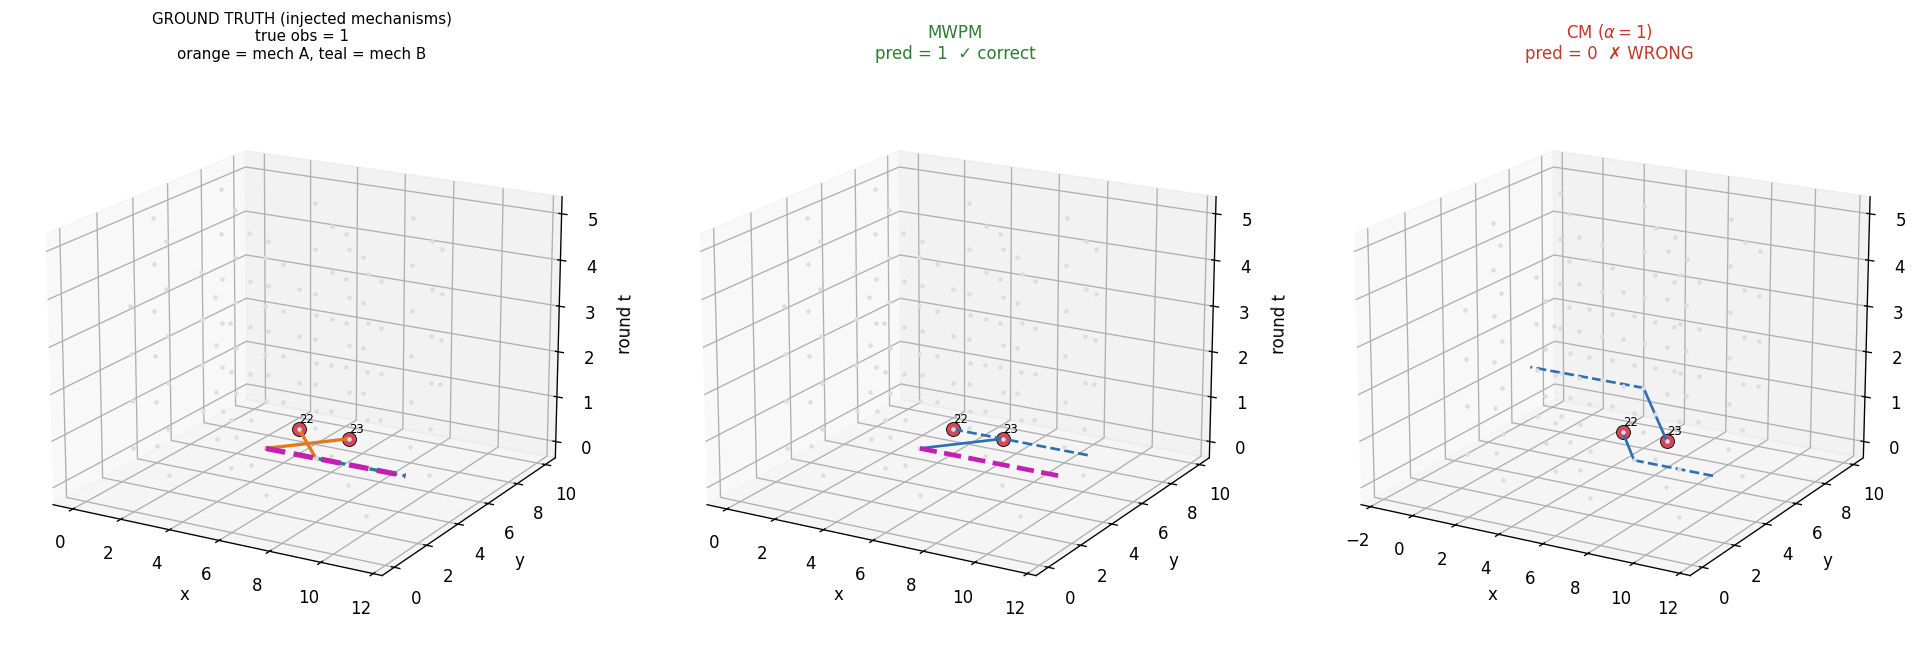

In [7]:
i, j, w, c = picked[0]
show_pair(i, j, f"EXAMPLE 1 — composition {c}: ordinary edge + correlated hyperedge")

EXAMPLE 2 — composition (3, 4)
  mechanism A (orange): Y28[coords 6,4]  during DEPOLARIZE2, tick 4
      detectors=(16, 21, 22)  obs_flip=0  p=4.00e-05
  mechanism B (teal)  : Y27[coords 5,5]  during DEPOLARIZE2, tick 5
      detectors=(21, 22, 25, 26)  obs_flip=0  p=1.20e-04


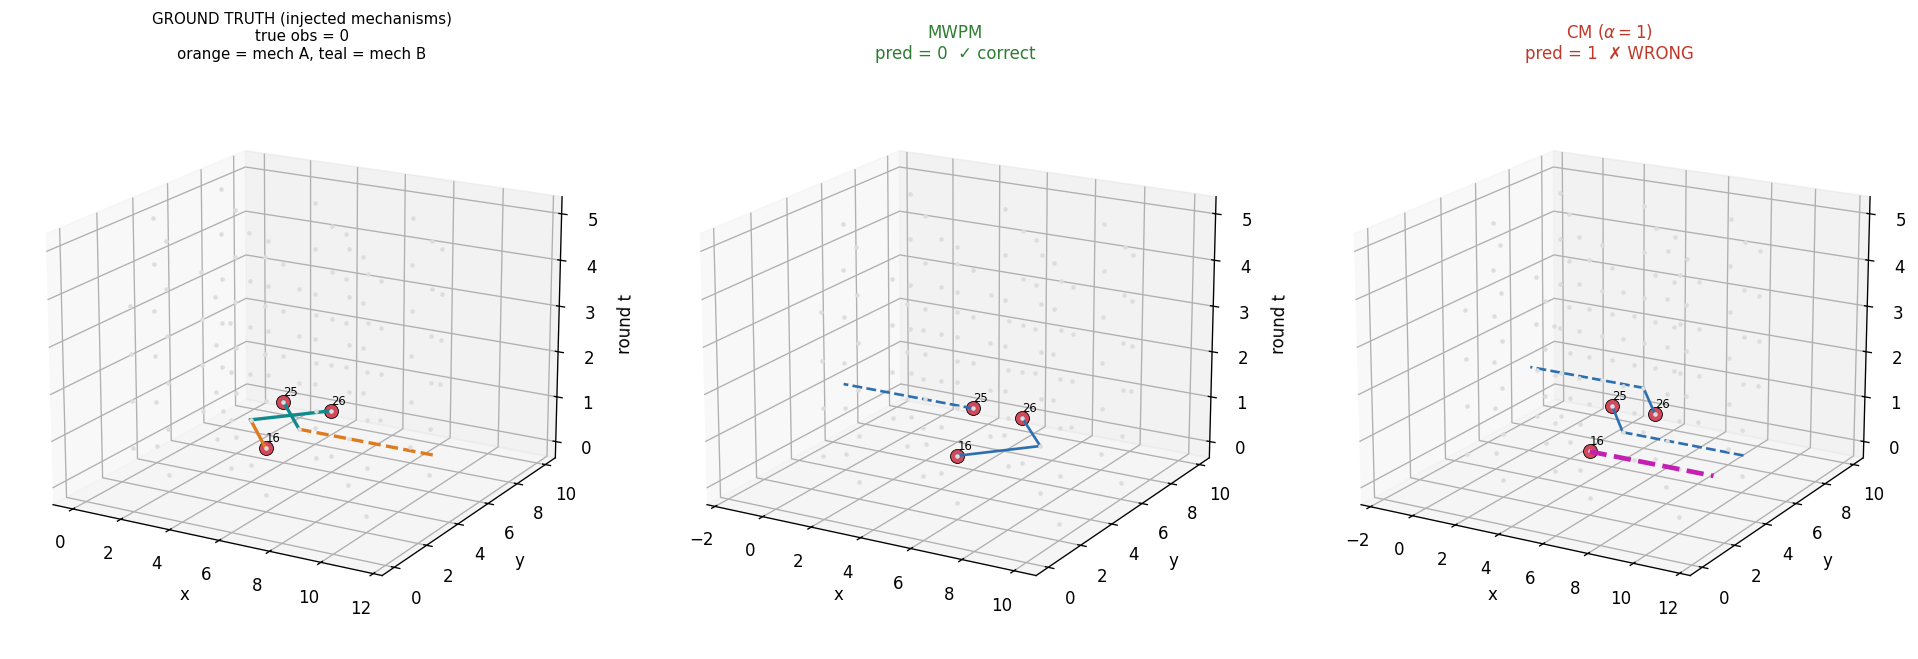

In [8]:
i, j, w, c = picked[1]
show_pair(i, j, f"EXAMPLE 2 — composition {c}")

EXAMPLE 3 — composition (2, 3)
  mechanism A (orange): Y31[coords 9,5]  during DEPOLARIZE2, tick 4
      detectors=(11, 23, 27)  obs_flip=0  p=5.33e-05
  mechanism B (teal)  : Y9[coords 9,1]  during DEPOLARIZE2, tick 11
      detectors=(18, 41)  obs_flip=1  p=4.00e-05


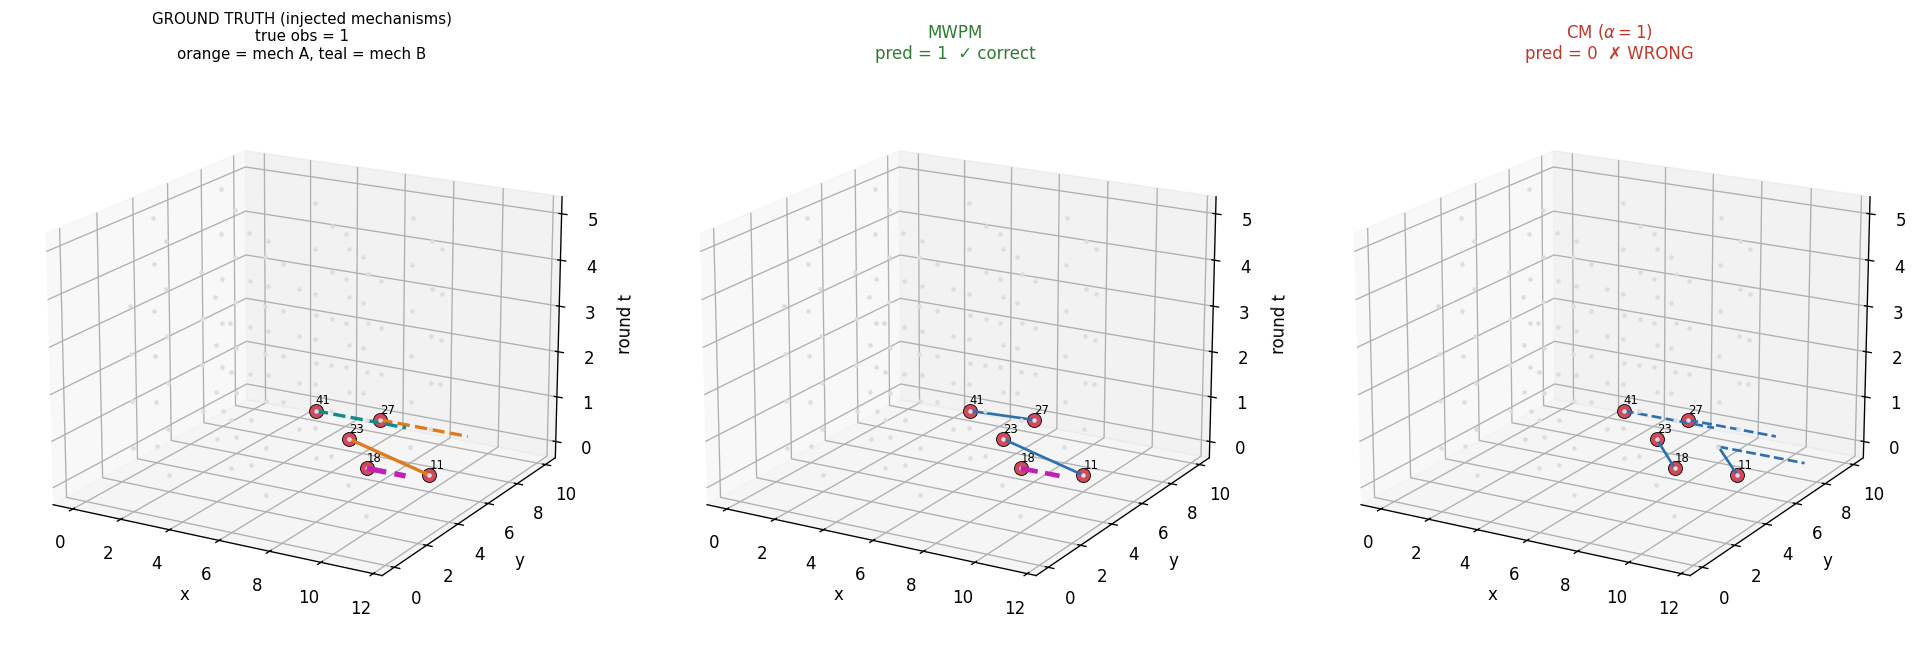

In [9]:
i, j, w, c = picked[2]
show_pair(i, j, f"EXAMPLE 3 — composition {c}")

## 6. Cause census: is it always DEPOLARIZE2?

The three examples all happened to be CNOT (`DEPOLARIZE2`) Y errors. Is that selection bias from
picking the most probable pairs, or structural? For every mechanism appearing in a failing pair we ask
stim for **all** equivalent circuit-level causes (`reduce_to_one_representative_error=False`) and
classify each pair.

In [10]:
uniq = sorted(set(i for i, j, w in cm_only) | set(j for i, j, w in cm_only))
cause = {}
for i in uniq:
    pr_, dets, ob_, ce = mechs[i]
    f = stim.DetectorErrorModel()
    tg = [stim.target_relative_detector_id(d) for d in dets]
    if ob_:
        tg.append(stim.target_logical_observable_id(0))
    f.append(stim.DemInstruction("error", [0.01], tg))
    try:
        ex = circ.explain_detector_error_model_errors(
            dem_filter=f, reduce_to_one_representative_error=False)
        cause[i] = {loc.instruction_targets.gate if loc.instruction_targets else "?"
                    for loc in ex[0].circuit_error_locations}
    except Exception:
        cause[i] = {"?"}

strict_free = [(i, j) for i, j, w in cm_only
               if "DEPOLARIZE2" not in cause[i] and "DEPOLARIZE2" not in cause[j]]
weak_free = [(i, j) for i, j, w in cm_only
             if (cause[i] - {"DEPOLARIZE2"}) and (cause[j] - {"DEPOLARIZE2"})]
n_dep2_both = sum(1 for i, j, w in cm_only
                  if "DEPOLARIZE2" in cause[i] and "DEPOLARIZE2" in cause[j])
print(f"failing pairs where BOTH mechanisms have DEPOLARIZE2 among their causes: "
      f"{n_dep2_both}/{len(cm_only)}")
print(f"pairs with NEITHER mechanism DEPOLARIZE2-caused (strict):              "
      f"{len(strict_free)}/{len(cm_only)}")
print(f"pairs where both mechanisms have a non-DEPOLARIZE2 alternative (weak): "
      f"{len(weak_free)}/{len(cm_only)}")

failing pairs where BOTH mechanisms have DEPOLARIZE2 among their causes: 359/359
pairs with NEITHER mechanism DEPOLARIZE2-caused (strict):              0/359
pairs where both mechanisms have a non-DEPOLARIZE2 alternative (weak): 0/359


**Answer: no.** Every one of the failing pairs consists of two mechanisms that are both caused by
`DEPOLARIZE2` (two-qubit gate noise), and no pair can be attributed — even as an alternative
explanation — to a DEPOLARIZE2-free combination. Single-qubit data depolarization
(`DEPOLARIZE1`, whose data-qubit Y makes a *vertical* X+Z hyperedge with no space-time reach) and
measurement/reset flips (`X_ERROR`, single-sector time-like edges) never assemble a
distance-reducing configuration. The effective-distance loss of full-strength CM is, at this noise
model, **entirely a two-qubit-gate-noise phenomenon**: only CNOT-propagated Y / mixed errors have the
diagonal space-time reach that lets a two-fault configuration plus the boosted phantom cloud complete
an observable-crossing detour.

## 7. What the pictures show

In every example the pattern is the same:

1. **Ground truth**: two independent physical faults — typically one **correlated hyperedge** (a
   data-qubit Y or a mixed two-qubit CNOT error, whose decomposition is one X-edge *plus* one Z-edge)
   and one more fault. Under a distance-5 code these are guaranteed correctable, and indeed —
2. **MWPM decodes them correctly**: its matching reproduces the ground-truth chains (up to homology),
   because each subgraph sees at most 2 faults and the honest weights point to the true explanation.
3. **CM(α=1) decodes them wrongly**: the first pass finds the true edges, but believing them with
   certainty discounts *every* hyperedge partner of every selected edge to O(1) weight. The second
   pass then reroutes part of the matching through this **phantom cloud** — typically exiting through
   a *different boundary edge* that carries the observable flag — and flips the logical prediction.
   The chain that crosses the logical operator is mostly **not made of physical errors**: it is 2 real
   faults plus ~4 decoder-donated near-free edges.

This is the microscopic content of the effective-distance loss: CM(α=1) turns weight-2 error
configurations into logical errors (fault distance 3 → 2, LER floor ∝ p²), which is why it falls
behind MWPM at low p, and why the damped (Pearl-α) variant — which re-prices the phantom edges — keeps
the full distance while retaining the correlation benefit.